In [2]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Define the directory path
# adjust this path to match the location in the workspace
# original notebook used a different user and path which caused FileNotFoundError

data_dir = r'C:\Users\ashok\Downloads\Blood Cell\archive\dataset2-master\dataset2-master\images\TRAIN'

# verify that the directory exists
if not os.path.isdir(data_dir):
    raise FileNotFoundError(f"Dataset directory not found: {data_dir}")

# Define the class labels - folder names are all uppercase in this dataset
class_labels = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

# Initialize lists to hold file paths and labels
filepaths = []t
labels = []

# Loop through each class directory and gather file paths and labels
for label in class_labels:
    class_dir = os.path.join(data_dir, label)
    for file in os.listdir(class_dir):
        if file.endswith('.jpeg') or file.endswith('.png'):  # Ensure file is an image
            filepaths.append(os.path.join(class_dir, file))
            labels.append(label)

# Create a DataFrame from the file paths and labels
bloodCell_df = pd.DataFrame({
    'filepaths': filepaths,
    'labels': labels
})

# Shuffle the DataFrame
bloodCell_df = bloodCell_df.sample(frac=1).reset_index(drop=True)

bloodCell_df.head()

,filepaths,labels
0,C:\Users\ashok\Downloads\Blood Cell\archive\da...,MONOCYTE
1,C:\Users\ashok\Downloads\Blood Cell\archive\da...,MONOCYTE
2,C:\Users\ashok\Downloads\Blood Cell\archive\da...,LYMPHOCYTE
3,C:\Users\ashok\Downloads\Blood Cell\archive\da...,MONOCYTE
4,C:\Users\ashok\Downloads\Blood Cell\archive\da...,NEUTROPHIL


Found 7965 validated image filenames belonging to 4 classes.
Found 1992 validated image filenames belonging to 4 classes.


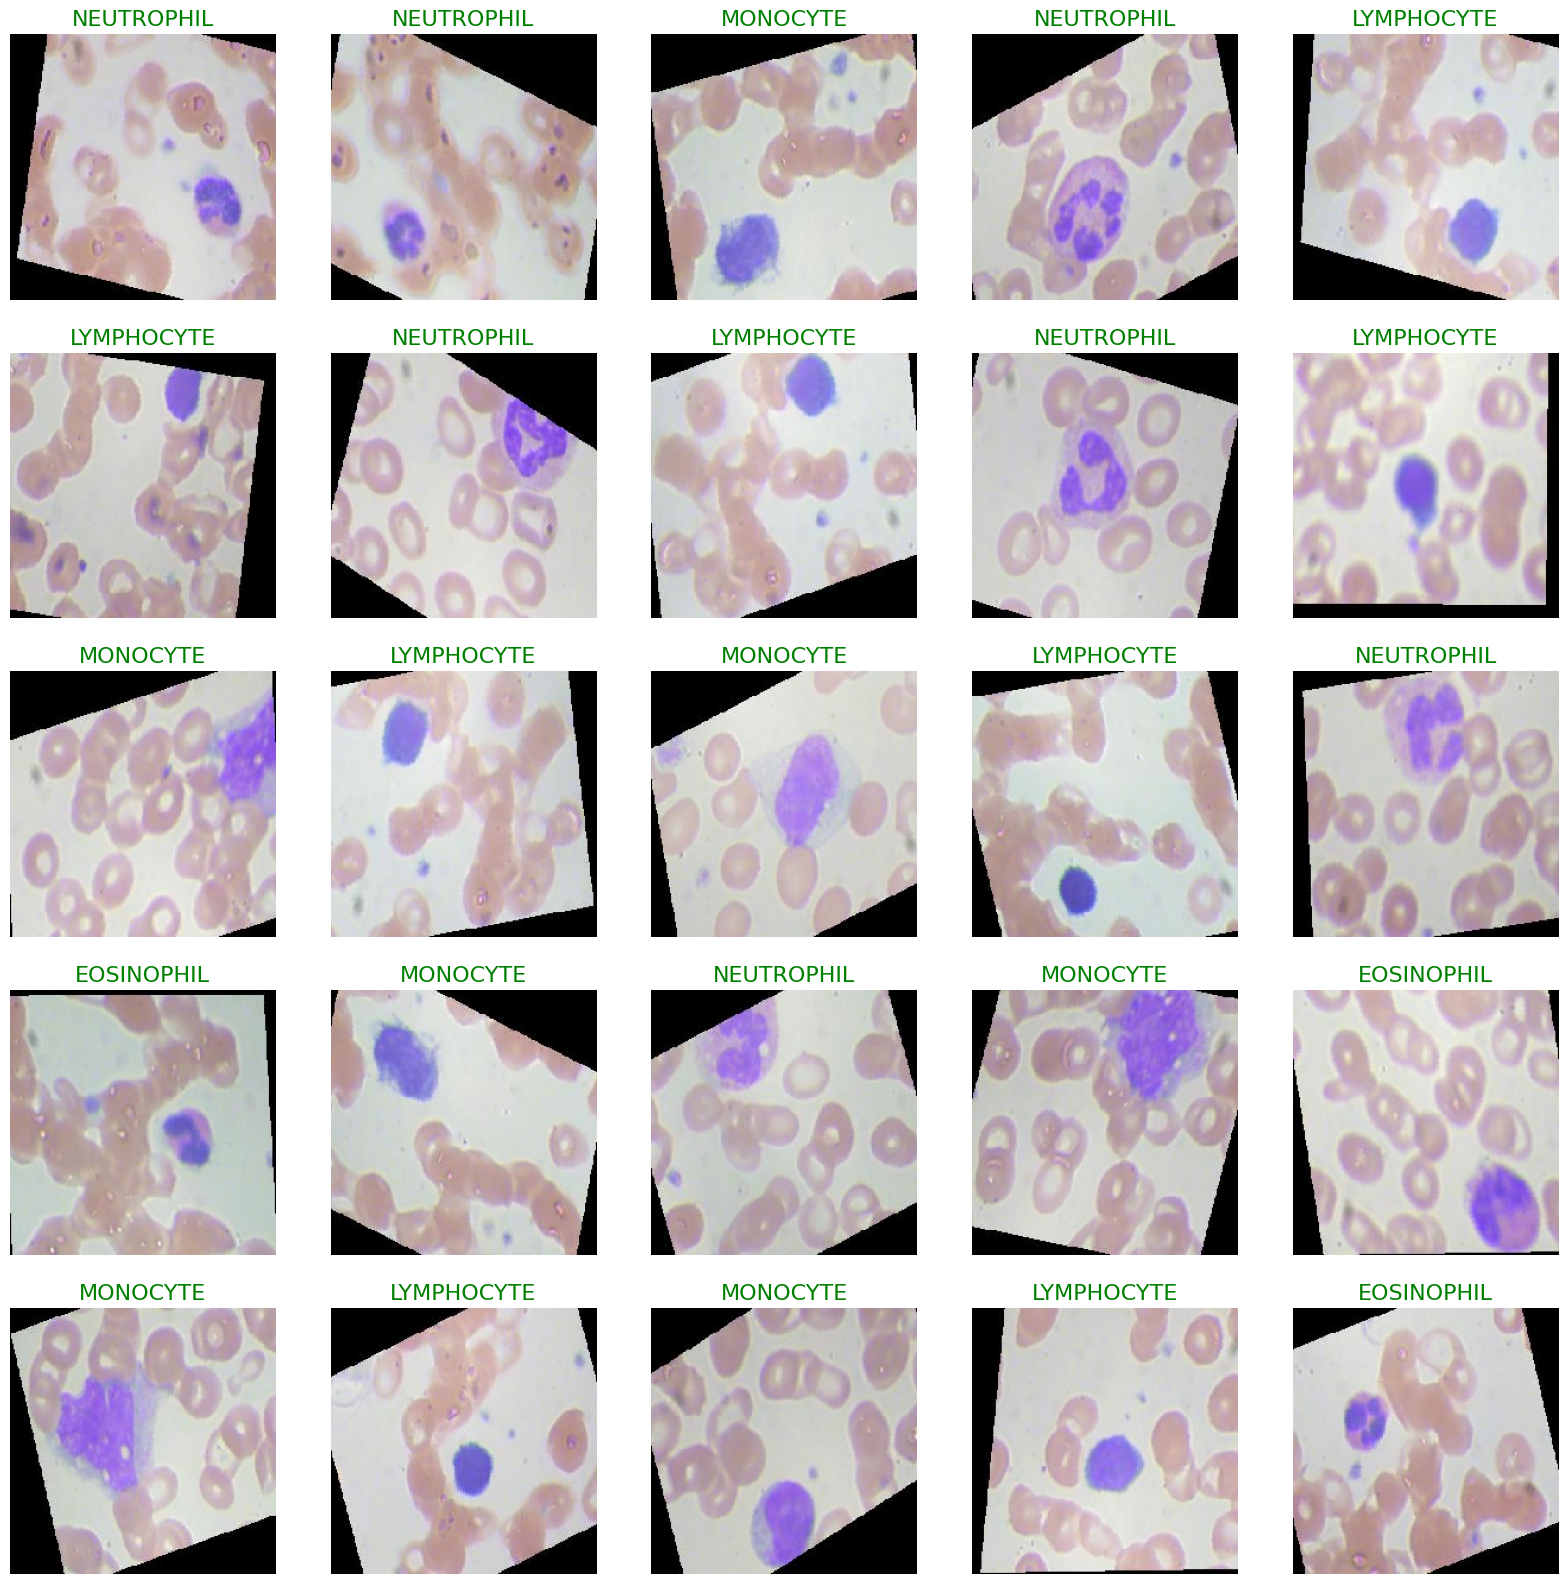

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# split the dataframe into train/validation
train_df, val_df = train_test_split(bloodCell_df, test_size=0.2, stratify=bloodCell_df['labels'], random_state=42)

# create image data generators with preprocessing
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   horizontal_flip=True,
                                   vertical_flip=True)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# flow from dataframe
train = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# using val_df for test/validation generator
test = test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# helper to visualize images from a generator

def show_knee_images(image_gen):
    class_indices = image_gen.class_indices
    classes = list(class_indices.keys())
    images, labels = next(image_gen)

    plt.figure(figsize=(20, 20))
    length = len(labels)

    r = min(length, 25)

    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image = (images[i] + 1) / 2
        plt.imshow(image)

        index = np.argmax(labels[i])
        class_name = classes[index]
        plt.title(class_name, color="green", fontsize=16)
        plt.axis("off")

    plt.show()

show_knee_images(train)

In [8]:
train_images, test_images = train_test_split(bloodCell_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(bloodCell_df, test_size=0.2, random_state=42)

print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)


image_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train = image_gen.flow_from_dataframe(
    dataframe=train_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(244, 244),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=8,
    shuffle=False
)

test = image_gen.flow_from_dataframe(
    dataframe=test_images,
    x_col="filepaths",
    y_col="labels",
    target_size=(244, 244),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=8,
    shuffle=False
)

val = image_gen.flow_from_dataframe(
    dataframe=val_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(244, 244),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=8,
    shuffle=False
)

(7965, 2)
(2988, 2)
(1992, 2)
(6969, 2)
Found 7965 validated image filenames belonging to 4 classes.
Found 2988 validated image filenames belonging to 4 classes.
Found 1992 validated image filenames belonging to 4 classes.


In [9]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3),
                        activation='relu', input_shape=(224, 224, 3)),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3, 3)),

    keras.layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1),
                        activation='relu', padding="same"),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.MaxPool2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

C:\Users\ashok\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 73, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 73, 73, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 73, 73, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             

 Total params: 15,610,500 (59.55 MB)

 Trainable params: 15,604,612 (59.53 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [12]:
history = model.fit(train, epochs=5, validation_data=val, verbose=1)

Epoch 1/5
996/996 ━━━━━━━━━━━━━━━━━━━━ 1067s 1s/step - accuracy: 0.5571 - loss: 1.0133 - val_accuracy: 0.7169 - val_loss: 0.7087
Epoch 2/5
996/996 ━━━━━━━━━━━━━━━━━━━━ 1083s 1s/step - accuracy: 0.7104 - loss: 0.7039 - val_accuracy: 0.8138 - val_loss: 0.4398
Epoch 3/5
996/996 ━━━━━━━━━━━━━━━━━━━━ 1072s 1s/step - accuracy: 0.8131 - loss: 0.4569 - val_accuracy: 0.8469 - val_loss: 0.3796
Epoch 4/5
996/996 ━━━━━━━━━━━━━━━━━━━━ 1066s 1s/step - accuracy: 0.8753 - loss: 0.3128 - val_accuracy: 0.9001 - val_loss: 0.2363
Epoch 5/5
996/996 ━━━━━━━━━━━━━━━━━━━━ 1076s 1s/step - accuracy: 0.9119 - loss: 0.2281 - val_accuracy: 0.9337 - val_loss: 0.1634


In [13]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1)  # pick class with highest probability

labels = (train.class_indices)
labels = dict((v, k) for k, v in labels.items())
pred2 = [labels[k] for k in pred]




374/374 ━━━━━━━━━━━━━━━━━━━━ 97s 258ms/step


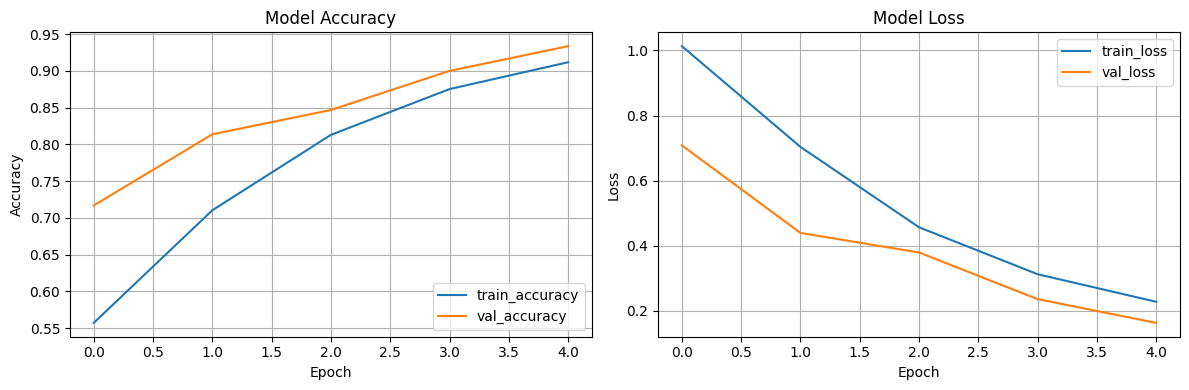

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report

y_test = test_images.labels  # set y_test to the expected output

print(classification_report(y_test, pred2))
print("Accuracy of the Model: ", "{:.1f}%".format(accuracy_score(y_test, pred2) * 100))

              precision    recall  f1-score   support

  EOSINOPHIL       0.88      0.93      0.90       736
  LYMPHOCYTE       0.97      1.00      0.99       757
    MONOCYTE       1.00      0.98      0.99       740
  NEUTROPHIL       0.93      0.88      0.90       755

    accuracy                           0.95      2988
   macro avg       0.95      0.95      0.94      2988
weighted avg       0.95      0.95      0.95      2988

Accuracy of the Model:  94.5%


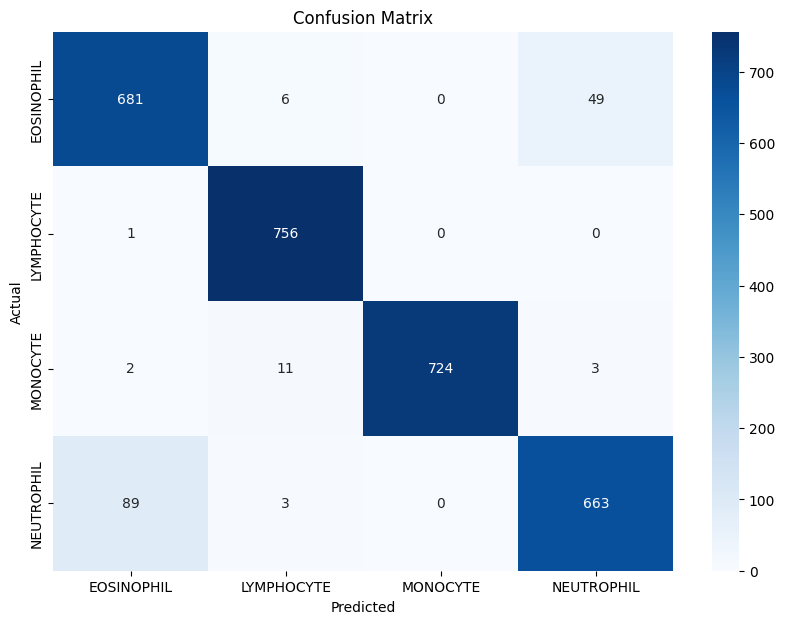

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_labels = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

cm = confusion_matrix(y_test, pred2)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
model.save("Blood Cell.keras")
print("Model saved as 'Blood Cell.keras'")

Model saved as 'Blood Cell.keras'
